In [42]:
!pip install google-genai

In [43]:
from google import genai

client = genai.Client(api_key="AQ.Ab8RN6LaIL5Bru16ah0noB2W62fNsqOY5DZKDUhnOfMUDMGDmg")

model="gemini-3-flash-preview"
prompt="Explain quantum computing in one sentence."

# Generate content
response = client.models.generate_content(
    model= model,
    contents=prompt
)

print(response.text)

Quantum computing leverages the principles of quantum mechanics, such as superposition and entanglement, to process vast amounts of information simultaneously and solve complex problems far beyond the reach of classical computers.


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os;
file_path = os.path.join('/kaggle/input/datasets/mlg-ulb/creditcardfraud', 'creditcard.csv')

# Create the DataFrame
data = pd.read_csv(file_path)

In [45]:
metadata = {
  "features": {
    "Time": "Number of seconds elapsed between this transaction and the first transaction in the dataset",
    "V1": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V2": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V3": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V4": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V5": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V6": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V7": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V8": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V9": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V10": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V11": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V12": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V13": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V14": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V15": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V16": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V17": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V18": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V19": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V20": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V21": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V22": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V23": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V24": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V25": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V26": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V27": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "V28": "Result of a PCA dimensionality reduction to protect user identities and sensitive features",
    "Amount": "Transaction amount",
    "Class": "1 for fraudulent transactions, 0 otherwise"
  }
}

In [57]:
#1. Time since previous transaction
data['time_since_previous_transaction'] = data['Time'].diff().fillna(0)

# 2. Transaction hour
data['hour'] = (data['Time']//3600) % 24

# 3. is_night_time
data['is_night_time'] = data['hour'].apply(lambda x: 1 if 0 <= x <= 6 else 0)

#1. Log transformed
data['log_amount'] = np.log(data['Amount'] + 1)

#2. Amount Z-score
data['amount_zscore'] = (data['Amount'] - data['Amount'].mean()) / data['Amount'].std()

#3. Rolling amount mean (compute over last 60s)

    # 3.1 Create a temporary datetime index using the 'Time' column (seconds)
data.index = pd.to_datetime(data['Time'], unit='s')

    # 3.2 Calculate the rolling mean of 'Amount' over the last 60 seconds
data['rolling_amount_mean_60s'] = (
    data['Amount']
    .rolling(window='60s')
    .mean()
)

    #3.3 Reset the index back to the default (0, 1, 2...)
data = data.reset_index(drop=True)

In [58]:
sample_data = pd.concat([data[data['Class']==0].head(100), data[data['Class']==1].head(100)]).to_json(orient='records')

In [59]:
sample_df = pd.concat([
    data[data['Class'] == 0].head(100), 
    data[data['Class'] == 1].head(100)
])

# 1. Print first 5 rows
print(sample_df.head(5))

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V27       V28  Amount  Class  \
0  0.098698  0.363787  ...  0.133558 -0.021053  149.62      0   
1  0.085102 -0.255425  ... -0.008983  0.014724    2.69      0   
2  0.247676 -1.514654  ... -0.055353 -0.059752  378.66      0   
3  0.377436 -1.387024  ...  0.062723  0.061458  123.50      0   
4 -0.270533  0.817739  ...  0.219422  0.215153   69.99      0   

   time_since_previous_transaction  hour  is_night_time  log_amount  \
0                              0.0   0.0           

In [60]:
import json

# Manual features already engineered by domain expert, with definitions
manual_features_info = {
    "delta_time": "Seconds elapsed since the previous transaction",
    "transaction_hour": "Hour of day derived from Time (0-23)",
    "is_night_time": "Binary flag: 1 if transaction hour is between 0-6",
    "log_amount": "Log-transformed transaction amount, log(Amount+1)",
    "amount_zscore": "Standardized amount: (Amount - mean) / std",
    "rolling_amount_mean_60s": "Rolling mean of Amount over a 60-second window"
}

prompt = f"""
I am conducting research on hybrid (manual + LLM-assisted) feature engineering
for financial fraud detection. A domain expert has already engineered a set of
features. Your job is to propose NEW features that are genuinely complementary
to these — not variations, restatements, or trivial recombinations of them.

Dataset Metadata: {json.dumps(metadata)}
Sample Data (JSON): {sample_data}

Manually engineered features (already in the dataset):
{json.dumps(manual_features_info, indent=2)}

Task:
1. Review the manual features above and identify what kinds of fraud signals
   they already capture (e.g., temporal patterns, amount distribution, local
   transaction density).
2. Identify categories of fraud-relevant signal that are NOT yet captured by
   the manual features (e.g., higher-order interactions between PCA
   components, distributional anomalies, ratio/magnitude relationships,
   non-linear transformations, cross-feature consistency checks).
3. Propose 6-8 NEW features that fill these gaps. For each proposed feature:
   a. Give a short name and one-line description.
   b. State explicitly which manual feature(s) it is complementary to, and
      briefly justify why it is NOT redundant with them (e.g., different
      information source, different functional form, captures interaction
      rather than a single variable).
   c. If a feature is conceptually similar to any manual feature, DO NOT
      propose it — skip it instead of forcing a justification.
4. Provide Python code using 'pandas' (and 'numpy' if needed) to create these
   features. Assume the dataframe is named 'df' and already contains the
   manual features listed above.
5. Explain the fraud-detection logic behind each feature in 2-3 sentences.

Output format:
- A numbered list of proposed features, each with: name, description,
  complementarity justification, and logic explanation.
- A single Python function `def engineer_hybrid_features(df): ...` implementing
  all proposed features and returning the augmented dataframe.
"""

response = client.models.generate_content(model="gemini-3-flash-preview",contents=prompt)
print(response.text)

This analysis proposes new features for the fraud detection dataset, specifically targeting "blind spots" left by the existing temporal and magnitude-based features.

### 1. Signal Analysis of Existing Features
The current set of manual features focuses on:
*   **Time-Series Context:** `delta_time` and `rolling_amount_mean_60s` capture sudden bursts or "velocity" in spending.
*   **Temporal Seasonality:** `transaction_hour` and `is_night_time` capture high-risk windows (e.g., "the graveyard shift").
*   **Univariate Magnitude:** `log_amount` and `amount_zscore` identify "heavy hitters" or outliers in the raw dollar value.

### 2. Identification of Gaps
The current features miss several critical fraud indicators:
*   **Latent Anomaly Magnitude:** While the PCA features (V1-V28) are provided, we aren't measuring how far a transaction is from the "center" of the latent space (multi-dimensional outlier detection).
*   **Feature Complexity/Entropy:** Fraudulent transactions often exhibit un

In [61]:
import numpy as np

def engineer_hybrid_features(df):
    
    v_cols = [f'V{i}' for i in range(1, 29)]
    
    # 1. PCA Spatial Magnitude (Distance from latent origin)
    df['pca_total_magnitude'] = np.sqrt(np.square(df[v_cols]).sum(axis=1))
    
    # 2. Amount Fractionality (Precision check)
    # Using np.modf to get the fractional part
    df['amount_fractionality'] = np.modf(df['Amount'])[0]
    
    # 3. PCA Skewness (Internal distribution of the latent vector)
    df['pca_skewness'] = df[v_cols].skew(axis=1)
    
    # 4. Cyclic Time (Circular continuity)
    # df['hour'] is assumed to be present from manual features
    df['time_cyclic_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    
    # 5. V-Range Magnitude (Latent Volatility)
    df['v_range_magnitude'] = df[v_cols].max(axis=1) - df[v_cols].min(axis=1)
    
    # 6. PCA Latent Velocity (Identity drift)
    # Calculate distance between current V-vector and previous V-vector
    # Fillna(0) for the first record
    pca_diffs = df[v_cols].diff().fillna(0)
    df['pca_latent_velocity'] = np.sqrt(np.square(pca_diffs).sum(axis=1))
    
    # 7. Amount-to-Latent Ratio (Consistency check)
    # Adding a small epsilon to avoid division by zero
    df['amount_to_v1_ratio'] = df['Amount'] / (df['V1'].abs() + 1e-5)
    
    # 8. Amount Integer Flag (Categorical precision)
    df['amount_is_integer'] = (df['Amount'] % 1 == 0).astype(int)
    
    return df

In [62]:
df = engineer_hybrid_features(data)
print(df.head(5))
print(df.columns.tolist())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...  amount_zscore  rolling_amount_mean_60s  \
0  0.098698  0.363787  ...       0.244964                 149.6200   
1  0.085102 -0.255425  ...      -0.342474                  76.1550   
2  0.247676 -1.514654  ...       1.160684                 176.9900   
3  0.377436 -1.387024  ...       0.140534                 163.6175   
4 -0.270533  0.817739  ...      -0.073403                 144.8920   

   pca_total_magnitude  amount_fractionality  pca_skewness  time_cyclic_sin  \
0            

In [63]:
# List of the 10 engineered features
new_features = [
    'pca_total_magnitude', 'amount_fractionality', 'pca_skewness', 'time_cyclic_sin', 'v_range_magnitude', 
    'pca_latent_velocity', 'amount_to_v1_ratio','amount_is_integer'
]

# Print the first 5 rows of these specific columns
print(df[new_features].head(10))

   pca_total_magnitude  amount_fractionality  pca_skewness  time_cyclic_sin  \
0             3.911559                  0.62      1.288715              0.0   
1             2.674524                  0.69      1.423030              0.0   
2             6.080512                  0.66     -0.515397              0.0   
3             4.284356                  0.50      0.791537              0.0   
4             3.565131                  0.99     -0.162977              0.0   
5             2.553739                  0.67      0.960517              0.0   
6             2.816984                  0.99      0.166508              0.0   
7             6.179383                  0.80     -0.897090              0.0   
8             5.091262                  0.20      2.562968              0.0   
9             2.985308                  0.68      0.287089              0.0   

   v_range_magnitude  pca_latent_velocity  amount_to_v1_ratio  \
0           3.896154             0.000000          110.029501   


In [64]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
)

def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, method):
    """Calculates and returns key metrics, including AUPRC."""

    # Calculate Precision-Recall AUC (AUPRC) - Recommended for imbalance
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Calculate other key metrics
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    recall = recall_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)

    # Calculate Confusion Matrix for review
    cm = confusion_matrix(y_true, y_pred_class)
    print("confusion_matrix:\n",cm)

    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Method': method,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'F1-Score': f1,
        'True Positives (TP)': tp,
        'False Negatives (FN)': fn  # Missed Fraud - critical risk
    }
    return results

final_results = []

In [65]:
from sklearn.model_selection import train_test_split
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

cols = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'time_since_previous_transaction', 'hour', 'is_night_time', 'log_amount', 'amount_zscore', 'rolling_amount_mean_60s', 'pca_total_magnitude', 'amount_fractionality', 'pca_skewness', 'time_cyclic_sin', 'v_range_magnitude', 'pca_latent_velocity', 'amount_to_v1_ratio', 'amount_is_integer']
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), cols)
    ],
    remainder='passthrough'
)

In [67]:
## Handle Imbalance (SMOTE Example for Training Data)

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

LR - CW

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

lr_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        C=0.01,
    ))
])


lr_cw.fit(X_train, y_train)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = lr_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "LR","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[83093  2202]
 [   21   127]]
Model                         LR
Method                        CW
PR-AUC                  0.685839
ROC-AUC                 0.969195
Recall (Fraud)          0.858108
Precision (Fraud)        0.05453
F1-Score                0.102543
True Positives (TP)          127
False Negatives (FN)          21
dtype: object


In [69]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_cw.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_cw.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                   Feature  Coefficient
2                                scale__V4     1.489002
14  scale__time_since_previous_transaction     0.534070
13                           scale__Amount     0.185548
11                              scale__V22     0.180883
0                                scale__V1     0.118464
18             scale__amount_fractionality     0.022805
16                    scale__amount_zscore     0.022413
15                             scale__hour     0.000000
20                scale__v_range_magnitude     0.000000
21               scale__amount_to_v1_ratio     0.000000
19                  scale__time_cyclic_sin    -0.006939
12                              scale__V27    -0.092490
3                                scale__V7    -0.116693
10                              scale__V20    -0.157118
1                                scale__V3    -0.233941
17              scale__pca_total_magnitude    -0.238517
5                                scale__V9    -0

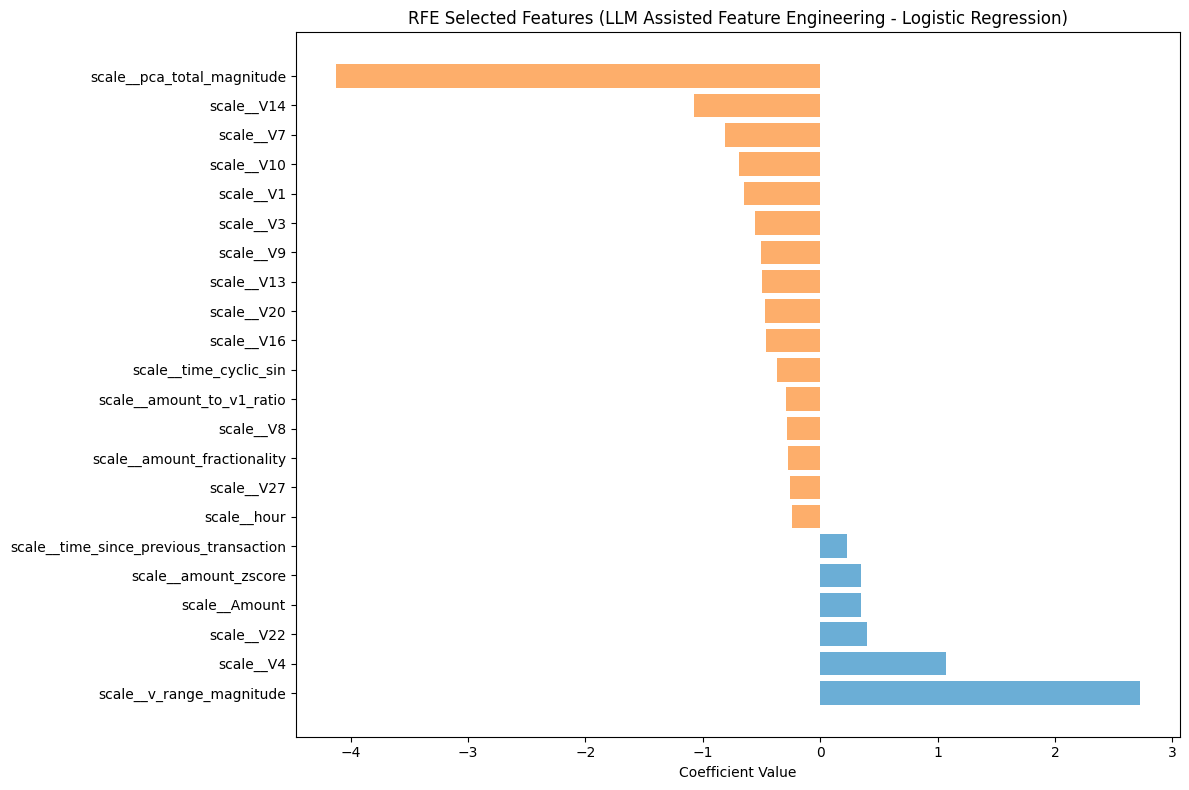

In [71]:
feature_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()
selector = lr_cw.named_steps['selector']
selected_mask = selector.support_
selected_features = feature_names[selected_mask]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get coefficients
coefs = selector.estimator_.coef_[0]


# Use absolute value for ranking
#importance = np.abs(coefs)
importance = coefs

# Sort
indices = np.argsort(importance)

sorted_importance = importance[indices]
sorted_features = np.array(selected_features)[indices]

# Soft professional color
#colors = cm.GnBu(np.linspace(0.3, 0.8, len(indices)))
colors = ['#6baed6' if c > 0 else '#fdae6b' for c in sorted_importance]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importance, color=colors)

plt.yticks(range(len(indices)), sorted_features)
plt.xlabel("Coefficient Value")
plt.title("RFE Selected Features (LLM Assisted Feature Engineering - Logistic Regression)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

LR - SMOTE

In [72]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=10)),
    ('classifier', LogisticRegression(
        random_state=42,
        C=0.01,
        max_iter=1000,
        solver='liblinear',
        penalty='l1',
        class_weight=None,
    ))
])

# Train on the SMOTE-resampled training data
lr_smote.fit(X_train, y_train)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = lr_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "LR", "SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[83388  1907]
 [   20   128]]
Model                         LR
Method                     SMOTE
PR-AUC                   0.68931
ROC-AUC                  0.96823
Recall (Fraud)          0.864865
Precision (Fraud)       0.062899
F1-Score                 0.11727
True Positives (TP)          128
False Negatives (FN)          20
dtype: object


In [73]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_smote.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_smote.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                      Feature  Coefficient
2                   scale__V4     1.501239
8                 scale__hour     0.611972
3                   scale__V5     0.479889
9  scale__pca_total_magnitude    -0.437358
4                   scale__V8    -0.467734
1                   scale__V3    -0.519485
5                  scale__V10    -0.698016
6                  scale__V12    -0.743286
7                  scale__V14    -0.848209
0                 scale__Time    -0.903531


RF - CW

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs = -1,
        class_weight='balanced',
        criterion='entropy',
        max_depth=30,
        max_features='sqrt',
        min_samples_split=2
    ))
])

rf_cw.fit(X_train, y_train)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = rf_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "RF","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[85292     3]
 [   38   110]]
Model                         RF
Method                        CW
PR-AUC                  0.813482
ROC-AUC                 0.937178
Recall (Fraud)          0.743243
Precision (Fraud)       0.973451
F1-Score                0.842912
True Positives (TP)          110
False Negatives (FN)          38
dtype: object


In [75]:
# 1. Get original names from preprocessor
feature_names = rf_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_cw.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 10 out of 44 features.
scale__V14                    0.268049
scale__pca_total_magnitude    0.157665
scale__V10                    0.153829
scale__v_range_magnitude      0.103036
scale__V4                     0.093470
scale__V12                    0.072445
scale__V17                    0.068500
scale__V11                    0.041051
scale__V7                     0.020984
scale__pca_latent_velocity    0.020971
dtype: float64


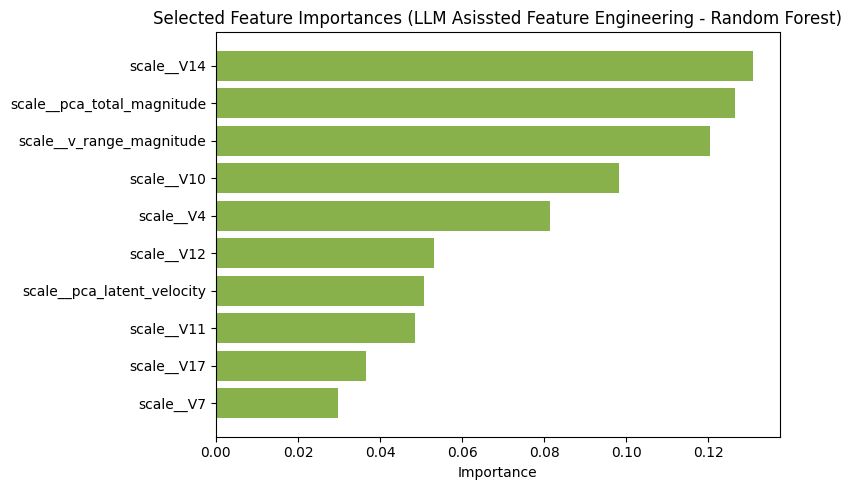

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#88B04B'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Asissted Feature Engineering - Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

RF - SMOTE

In [77]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs = -1,
        class_weight=None,
        criterion='entropy',
        max_depth=30,
        max_features='log2',
        min_samples_split=10
    ))
])

# Train on the SMOTE-resampled training data
rf_smote.fit(X_train, y_train)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = rf_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "RF","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[85239    56]
 [   28   120]]
Model                         RF
Method                     SMOTE
PR-AUC                   0.81503
ROC-AUC                 0.957924
Recall (Fraud)          0.810811
Precision (Fraud)       0.681818
F1-Score                0.740741
True Positives (TP)          120
False Negatives (FN)          28
dtype: object


In [78]:
# 1. Get original names from preprocessor
feature_names = rf_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_smote.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 11 out of 44 features.
scale__V14                    0.252038
scale__V10                    0.156785
scale__pca_total_magnitude    0.131338
scale__v_range_magnitude      0.099337
scale__V4                     0.094561
scale__V12                    0.086858
scale__V17                    0.068632
scale__V11                    0.040131
scale__pca_latent_velocity    0.025900
scale__V3                     0.025109
dtype: float64


XGB - CW

In [79]:
!pip install xgboost

In [80]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
xgb_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42),
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        max_depth=6,
        gamma=1,
        learning_rate=0.05,
        n_estimators=200,
        n_jobs=-1
    ))
])

xgb_cw.fit(X_train, y_train)
y_pred_proba_cw = xgb_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = xgb_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "XGB","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[85249    46]
 [   26   122]]
Model                        XGB
Method                        CW
PR-AUC                  0.829989
ROC-AUC                 0.968098
Recall (Fraud)          0.824324
Precision (Fraud)        0.72619
F1-Score                0.772152
True Positives (TP)          122
False Negatives (FN)          26
dtype: object


In [81]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_cw.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 22 out of 44
scale__V14                    0.623639
scale__V4                     0.056722
scale__V10                    0.031252
scale__V12                    0.030881
scale__v_range_magnitude      0.023885
scale__pca_total_magnitude    0.023844
scale__V21                    0.022643
scale__V20                    0.019446
scale__Amount                 0.019051
scale__V8                     0.018259
dtype: float32


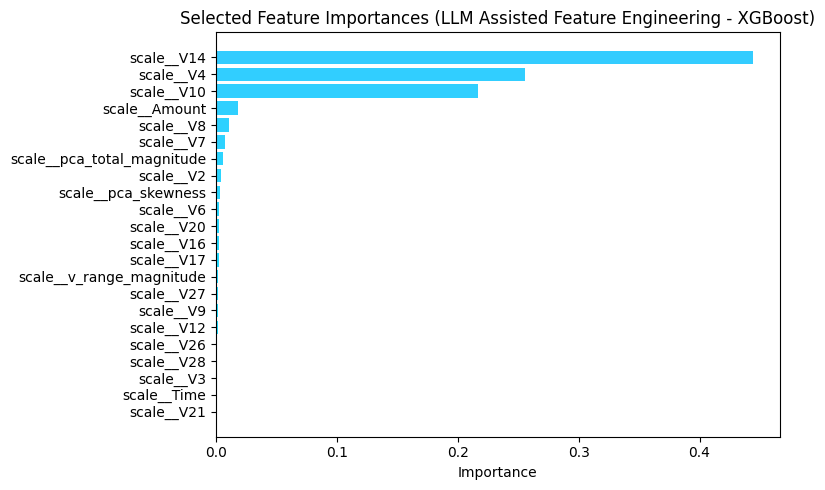

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = cm.cool(np.linspace(0.1, 0.2, len(indices)))


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances (LLM Assisted Feature Engineering - XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

XGB - SMOTE

In [83]:
xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42),
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=None,
        max_depth=None,
        gamma=1,
        learning_rate=0.1,
        n_estimators=100,
    ))
])

# Train on the SMOTE-resampled training data
xgb_smote.fit(X_train, y_train)
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = xgb_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "XGBoost","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[85158   137]
 [   26   122]]
Model                    XGBoost
Method                     SMOTE
PR-AUC                  0.806605
ROC-AUC                 0.965849
Recall (Fraud)          0.824324
Precision (Fraud)       0.471042
F1-Score                0.599509
True Positives (TP)          122
False Negatives (FN)          26
dtype: object


In [84]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_smote.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 22 out of 44
scale__V14                                0.581952
scale__V4                                 0.045623
scale__amount_is_integer                  0.040503
scale__v_range_magnitude                  0.037230
scale__V10                                0.034463
scale__time_since_previous_transaction    0.033709
scale__pca_total_magnitude                0.025294
scale__V8                                 0.021925
scale__V12                                0.017204
scale__V17                                0.016453
dtype: float32


In [85]:
results_df = pd.DataFrame(final_results)
print(results_df[[
    'Model',
    'Method',
    'PR-AUC',
    'ROC-AUC',
    'Recall (Fraud)',
    'Precision (Fraud)',
    'F1-Score',
    'True Positives (TP)',
    'False Negatives (FN)'
]])

     Model Method    PR-AUC   ROC-AUC  Recall (Fraud)  Precision (Fraud)  \
0       LR     CW  0.685839  0.969195        0.858108           0.054530   
1       LR  SMOTE  0.689310  0.968230        0.864865           0.062899   
2       RF     CW  0.813482  0.937178        0.743243           0.973451   
3       RF  SMOTE  0.815030  0.957924        0.810811           0.681818   
4      XGB     CW  0.829989  0.968098        0.824324           0.726190   
5  XGBoost  SMOTE  0.806605  0.965849        0.824324           0.471042   

   F1-Score  True Positives (TP)  False Negatives (FN)  
0  0.102543                  127                    21  
1  0.117270                  128                    20  
2  0.842912                  110                    38  
3  0.740741                  120                    28  
4  0.772152                  122                    26  
5  0.599509                  122                    26  


Generating SHAP for logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

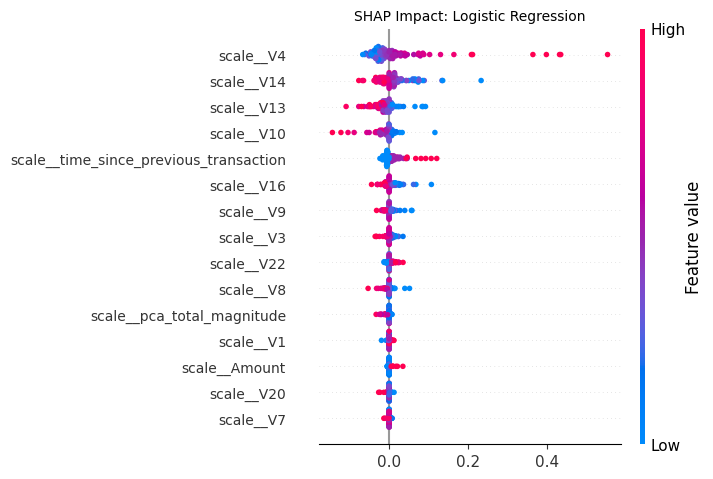

In [86]:
# --- LOGISTIC REGRESSION SHAP ---
import shap
import matplotlib.pyplot as plt
import numpy as np


model_name = 'logistic Regression' # Or 'lr_smote'
pipeline = lr_cw 

print(f"Generating SHAP for {model_name}...")

# 1. Transform data through preprocessor and RFE selector
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['selector'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['selector'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8,5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Logistic Regression", fontsize=10)
plt.show()

Generating SHAP for rf_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

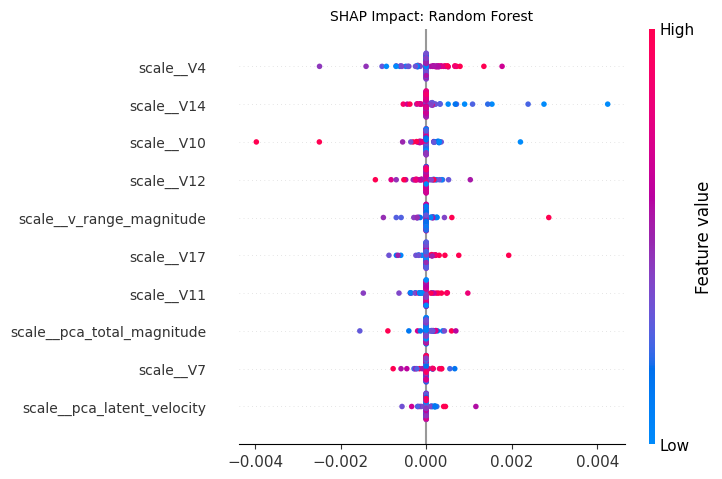

In [87]:
# --- RANDOM FOREST SHAP ---
model_name = 'rf_cw' # Or 'rf_smote'
pipeline = rf_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Random Forest", fontsize=10)
plt.show()

Generating SHAP for xgb_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

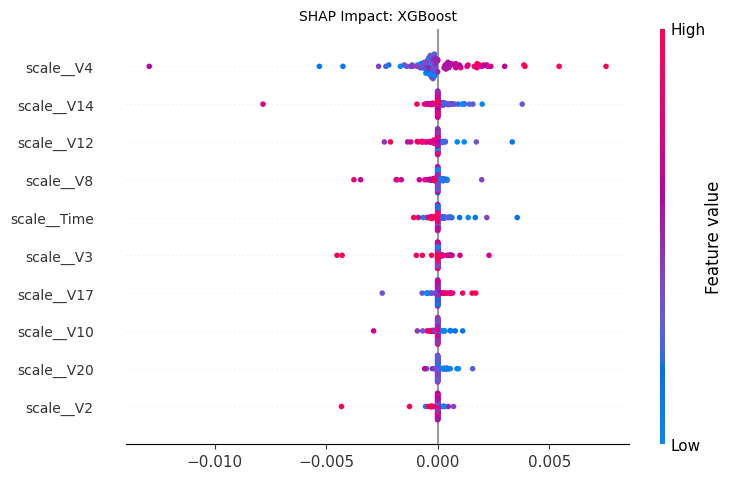

In [88]:
# --- XGBOOST SHAP ---
model_name = 'xgb_cw' # Or 'xgb_smote'
pipeline = xgb_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=10, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: XGBoost", fontsize=10)
plt.show()